## Задание

Постройте модель на основе полносвязных слоёв для классификации Fashion MNIST из библиотеки torchvision (datasets).
Получите качество на тестовой выборке не ниже 88%

Инструкция по выполнению задания

Скачайте тренировочную и тестовою часть датасета Fashion MNIST
Постройте модель, выбрав стартовую архитектуру
Обучите модель и сверьте качество на тестовой части с заданным порогом
Изменяйте архитектуру модели пока качество на тестовой части не будет выше порога. 
Вариации архитектуры можно реализовать через изменение количества слоёв, количества нейронов в слоях и использование регуляризации. 
Можно использовать различные оптимизаторы.

Кол-во изображений для тренировки 60000, для теста 10000
Кол-во классов тренировки 10, для теста 10
torch.Size([1, 28, 28]) 9


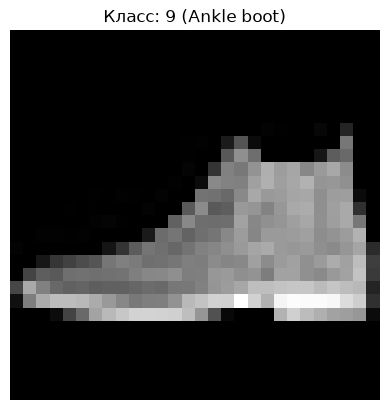

In [5]:
import torch
import torchvision
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

# Загрузка тренировочного датасета
train_dataset = torchvision.datasets.FashionMNIST(
    root='./2.data',  # Корневой каталог для хранения данных
    train=True,    # True для обучающей выборки, False для тестовой
    download=True, # Если True, данные будут скачаны из интернета
    transform=ToTensor()  # Преобразование данных в тензоры
)

# Загрузка тестового датасета
test_dataset = torchvision.datasets.FashionMNIST(
    root='./2.data',  # Корневой каталог тот же
    train=False,    # False для тестовой
    download=True,
    transform=ToTensor()
)

print(f'Кол-во изображений для тренировки {len(train_dataset)}, для теста {len(test_dataset)}')
print(f'Кол-во классов тренировки {len(train_dataset.classes)}, для теста {len(test_dataset.classes)}')

# Полюбопытствуем че там вообще есть
image, label = test_dataset[0] # 0 - ботинок, 1 - кафтан, 2 - варенки и т.д.

# image — это тензор [1, 28, 28], label это число, скаляр
print(image.shape, label)
image_np = image.squeeze().numpy() # убираем лишнюю размерность для imshow

plt.imshow(image_np, cmap='gray')
plt.title(f'Класс: {label} ({test_dataset.classes[label]})')
plt.axis('off')
plt.show()

## Загрузчики

In [6]:
BATCH_SIZE=256

train = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

## Модель №1

Модель полностью скопирована с "Занятия 2. Многослойная нейронная сеть". Показатели растут медленно, но какого-то плато за 10 эпох не ощущается, сначала прошел 10 эпох, потом выставил 100, сделал вывод что признаков переобучения нет. Чтобы узнать где плато, зарядил большое количество эпох.

Если выставить большое количество эпох, >500 то уже к 450-й эпохе требуемая 0.88 точность на тесте будет неуверенно, но достигнута и далее почти расти не будет.

Результаты: Эпоха 460, Трен. потери: 0.21341271476542695, Трен. точность: 0.9270166666666667, Тест потери: 0.32166153006255627, Тест точность: 0.8812

In [7]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 256),
    torch.nn.ReLU(),
    torch.nn.Linear(256, 10)
)
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)

In [17]:
loss = torch.nn.CrossEntropyLoss()
trainer = torch.optim.SGD(model.parameters(), lr=.01)
num_epochs = 500

import time

def train_model():
    time_summ = 0
    for ep in range(num_epochs):
        train_iters, train_passed  = 0, 0
        train_loss, train_acc = 0., 0.
        start=time.time()
        
        model.train()
        for X, y in train:
            trainer.zero_grad()
            y_pred = model(X)
            l = loss(y_pred, y)
            l.backward()
            trainer.step()
            train_loss += l.item()
            train_acc += (y_pred.argmax(dim=1) == y).sum().item()
            train_iters += 1
            train_passed += len(X)
        
        test_iters, test_passed  = 0, 0
        test_loss, test_acc = 0., 0.
        model.eval()
        for X, y in test:
            y_pred = model(X)
            l = loss(y_pred, y)
            test_loss += l.item()
            test_acc += (y_pred.argmax(dim=1) == y).sum().item()
            test_iters += 1
            test_passed += len(X)
        
        time_summ += time.time() - start
        print("Эпоха: {}, заняло: {:.3f}, Трен. потери: {}, Трен. точность: {}, Тест потери: {}, Тест точность: {}".format(
            ep, time.time() - start, train_loss / train_iters, train_acc / train_passed,
            test_loss / test_iters, test_acc / test_passed)
        )
    print(f'Итоговое время обучения {time_summ / 60} минут')

In [14]:
train_model()

Эпоха: 0, заняло: 3.230, Трен. потери: 0.3499263866784725, Трен. точность: 0.8786833333333334, Тест потери: 0.395019655674696, Тест точность: 0.8619
Эпоха: 1, заняло: 4.891, Трен. потери: 0.3491585952170352, Трен. точность: 0.8786333333333334, Тест потери: 0.39788218811154363, Тест точность: 0.8598
Эпоха: 2, заняло: 6.745, Трен. потери: 0.3487299514577744, Трен. точность: 0.8791166666666667, Тест потери: 0.40540526807308197, Тест точность: 0.8593
Эпоха: 3, заняло: 3.490, Трен. потери: 0.3476314721589393, Трен. точность: 0.8796333333333334, Тест потери: 0.3929414801299572, Тест точность: 0.8635
Эпоха: 4, заняло: 3.230, Трен. потери: 0.3475738988911852, Трен. точность: 0.8793666666666666, Тест потери: 0.396561548858881, Тест точность: 0.8609
Эпоха: 5, заняло: 5.823, Трен. потери: 0.34637249670130144, Трен. точность: 0.8796166666666667, Тест потери: 0.38732554093003274, Тест точность: 0.8618
Эпоха: 6, заняло: 3.980, Трен. потери: 0.3459098983318248, Трен. точность: 0.8800666666666667, Тес

Если по рекомендациям заменить SGD на Adam, то 88% уже на 50-й эпохе мелькает. Удивительно насколько этот оптимизатор дает большой прирост в эффективности!

In [16]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 256),
    torch.nn.ReLU(),
    torch.nn.Linear(256, 10)
)

trainer = torch.optim.Adam(model.parameters(), lr=.01)
num_epochs = 50
train_model()

Эпоха: 0, заняло: 3.595, Трен. потери: 0.5449213920755589, Трен. точность: 0.8045, Тест потери: 0.4317293971776962, Тест точность: 0.8383
Эпоха: 1, заняло: 5.018, Трен. потери: 0.37369830627390677, Трен. точность: 0.8619166666666667, Тест потери: 0.457514588534832, Тест точность: 0.8225
Эпоха: 2, заняло: 6.824, Трен. потери: 0.34461158881796167, Трен. точность: 0.8729166666666667, Тест потери: 0.40963319428265094, Тест точность: 0.8585
Эпоха: 3, заняло: 4.629, Трен. потери: 0.3227897568586025, Трен. точность: 0.8810333333333333, Тест потери: 0.3799612745642662, Тест точность: 0.8596
Эпоха: 4, заняло: 4.195, Трен. потери: 0.31102469760052703, Трен. точность: 0.8847666666666667, Тест потери: 0.38617509230971336, Тест точность: 0.858
Эпоха: 5, заняло: 3.988, Трен. потери: 0.29591736958381976, Трен. точность: 0.8910333333333333, Тест потери: 0.4014293745160103, Тест точность: 0.8554
Эпоха: 6, заняло: 3.589, Трен. потери: 0.29419637836040335, Трен. точность: 0.89025, Тест потери: 0.37598268

RMSprop явно хуже чем Adam в данной ситуации.

In [17]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 256),
    torch.nn.ReLU(),
    torch.nn.Linear(256, 10)
)

trainer = torch.optim.RMSprop(model.parameters(), lr=.01)
num_epochs = 50
train_model()

Эпоха: 0, заняло: 4.604, Трен. потери: 2.627944132241797, Трен. точность: 0.7586333333333334, Тест потери: 0.5947603784501553, Тест точность: 0.7885
Эпоха: 1, заняло: 3.560, Трен. потери: 0.4792787408575099, Трен. точность: 0.8266833333333333, Тест потери: 0.8626069948077202, Тест точность: 0.7533
Эпоха: 2, заняло: 4.361, Трен. потери: 0.4470310889660044, Трен. точность: 0.8369666666666666, Тест потери: 0.5323945611715317, Тест точность: 0.8194
Эпоха: 3, заняло: 3.596, Трен. потери: 0.40524329035840134, Трен. точность: 0.8502666666666666, Тест потери: 0.5765905544161797, Тест точность: 0.7943
Эпоха: 4, заняло: 3.186, Трен. потери: 0.3897841258886013, Трен. точность: 0.8587833333333333, Тест потери: 0.5910836376249791, Тест точность: 0.7841
Эпоха: 5, заняло: 3.380, Трен. потери: 0.3678410734267945, Трен. точность: 0.8650166666666667, Тест потери: 0.5706124765798449, Тест точность: 0.8159
Эпоха: 6, заняло: 3.145, Трен. потери: 0.3457397960601969, Трен. точность: 0.8731666666666666, Тест 

## Модель №2 -- Увеличиваем количество слоев

Увеличение количества слоев положительно повлияло на скорость обучения в самом начале. Но далее все как у предыдущей модели. К 50-й эпохе уже были показатели 88%. Однако увеличение количества эпох до 100 не повлияло на возможности модели перешагнуть этот показатель качества обучения, наоборот, показатель откатился к 87%, можно сделать вывод что сначала произошел ускоренный рост сходимости, но потом без ранней остановки произошло переобучение модели. Если совсем коротко: модель быстро учится, но и переобучается тоже быстро.

In [9]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 512),
    torch.nn.ReLU(),
    torch.nn.Linear(512, 256),
    torch.nn.ReLU(),
    torch.nn.Linear(256, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 10)
)

trainer = torch.optim.Adam(model.parameters(), lr=.01)
num_epochs = 100

In [10]:
train_model()

Эпоха: 0, заняло: 5.726, Трен. потери: 0.6003556188116682, Трен. точность: 0.7757166666666667, Тест потери: 0.45692960172891617, Тест точность: 0.8264
Эпоха: 1, заняло: 5.980, Трен. потери: 0.392482669049121, Трен. точность: 0.8567833333333333, Тест потери: 0.40642199888825414, Тест точность: 0.8535
Эпоха: 2, заняло: 5.400, Трен. потери: 0.3575105785689455, Трен. точность: 0.8711333333333333, Тест потери: 0.44040231555700304, Тест точность: 0.8418
Эпоха: 3, заняло: 7.539, Трен. потери: 0.337461937932258, Трен. точность: 0.8759, Тест потери: 0.3816672245040536, Тест точность: 0.8622
Эпоха: 4, заняло: 6.946, Трен. потери: 0.3236335223025464, Трен. точность: 0.8807166666666667, Тест потери: 0.38308089822530744, Тест точность: 0.8624
Эпоха: 5, заняло: 6.105, Трен. потери: 0.3097890800618111, Трен. точность: 0.8859833333333333, Тест потери: 0.37456840425729754, Тест точность: 0.8695
Эпоха: 6, заняло: 6.708, Трен. потери: 0.30584005022302585, Трен. точность: 0.8879666666666667, Тест потери: 

## Модель №3 -- добавляем выключение нейронов, и batch-нормализацию (Dropout, BatchNorm1d)

Добавляем случайное выключение нейронов (для предотвращения переобучения модели). 

Модель быстро учится (на эпохе <10 уже требуемое качество 88%), на эпохе <20 было обнаружено значение качества 89% это прорыв! Но если обучать далее, видно что переобучения не происходит. На эпохе >80 качество 89% уверенное и постоянное. По сравнению с моделью №1 это как двигатель v8 против газонокосилки.

In [15]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 256),
    torch.nn.BatchNorm1d(256),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),
    torch.nn.Linear(256, 128),
    torch.nn.BatchNorm1d(128),
    torch.nn.ReLU(),    
    torch.nn.Dropout(0.2),
    torch.nn.Linear(128, 10)
)

trainer = torch.optim.Adam(model.parameters(), lr=.01)
num_epochs = 100

In [16]:
train_model()

Эпоха: 0, заняло: 4.304, Трен. потери: 0.5007554112596715, Трен. точность: 0.81915, Тест потери: 0.5249471716582775, Тест точность: 0.7988
Эпоха: 1, заняло: 5.090, Трен. потери: 0.37923101110661284, Трен. точность: 0.86015, Тест потери: 0.3774306125938892, Тест точность: 0.8613
Эпоха: 2, заняло: 6.323, Трен. потери: 0.34348887623624597, Трен. точность: 0.8737333333333334, Тест потери: 0.3563232280313969, Тест точность: 0.8677
Эпоха: 3, заняло: 6.749, Трен. потери: 0.3210355058629462, Трен. точность: 0.8817333333333334, Тест потери: 0.35958795845508573, Тест точность: 0.8702
Эпоха: 4, заняло: 6.828, Трен. потери: 0.3003731877879893, Трен. точность: 0.8887833333333334, Тест потери: 0.3494242331013083, Тест точность: 0.869
Эпоха: 5, заняло: 7.167, Трен. потери: 0.2866060314660377, Трен. точность: 0.8928166666666667, Тест потери: 0.32911649718880653, Тест точность: 0.8854
Эпоха: 6, заняло: 5.828, Трен. потери: 0.2720340683105144, Трен. точность: 0.8985, Тест потери: 0.3379069358110428, Тес

# Что будет, если у Модели №3 выключить Dropout -- качество то же самое, но уверенность упала

Обучение медленнее в начале, но результат практически тот же. У предыдущего варианта время обучения 9,55 минут. У этого 8.77, можно сделать вывод что Dropout можно отключить? но если внимательнее посмотреть что получается можно заметить параметр который до этого как-то пропал из внимания. test_loss стал очень сильно больше. 

У модели с Dropout test_loss = 0.5 

В модели где dropout выключили, test_loss больше и доходит иногда до 0.99. Хотя итоговое время обучения закономерно меньше. Но результат тот же это 89% или 88% качество. test_loss это уверенность модели, все же думаю уверенность модели тоже важная штука, так как при увеличении классов (например в будущем мы захотим добавить еще 20 классов) скорей всего test_loss будет выступать запасом прочности. То есть модель у которой test_loss меньше возможно будет лучше масштабироваться.

In [19]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 256),
    torch.nn.BatchNorm1d(256),
    torch.nn.ReLU(),
    torch.nn.Linear(256, 128),
    torch.nn.BatchNorm1d(128),
    torch.nn.ReLU(),    
    torch.nn.Linear(128, 10)
)

trainer = torch.optim.Adam(model.parameters(), lr=.01)
num_epochs = 100

train_model()

Эпоха: 0, заняло: 6.065, Трен. потери: 0.45996377702723157, Трен. точность: 0.8310333333333333, Тест потери: 0.3912557058036327, Тест точность: 0.8605
Эпоха: 1, заняло: 6.606, Трен. потери: 0.34108634749625594, Трен. точность: 0.87365, Тест потери: 0.4602785289287567, Тест точность: 0.8319
Эпоха: 2, заняло: 4.883, Трен. потери: 0.3032423001020513, Трен. точность: 0.8860333333333333, Тест потери: 0.3848294705152512, Тест точность: 0.8628
Эпоха: 3, заняло: 5.200, Трен. потери: 0.2769731786022795, Трен. точность: 0.8963666666666666, Тест потери: 0.36865817829966546, Тест точность: 0.8685
Эпоха: 4, заняло: 4.497, Трен. потери: 0.2592515759011532, Трен. точность: 0.9038666666666667, Тест потери: 0.3540736887603998, Тест точность: 0.8752
Эпоха: 5, заняло: 5.192, Трен. потери: 0.23852620663795066, Трен. точность: 0.9098666666666667, Тест потери: 0.3432226464152336, Тест точность: 0.8756
Эпоха: 6, заняло: 5.068, Трен. потери: 0.22650011511559182, Трен. точность: 0.9143166666666667, Тест потери